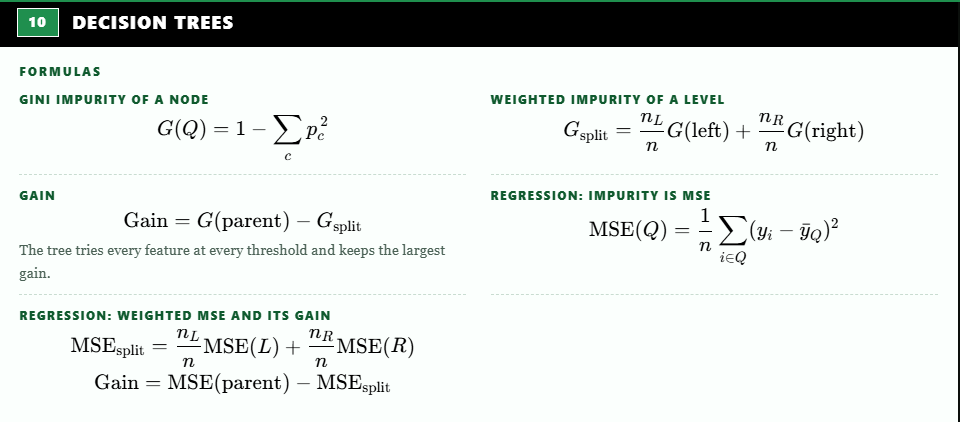


In [28]:
# 14. Classification tree — Gini · weighted Gini · gain

# (a) parents gini
    # A support team has 14 tickets: 8 escalated, 6 not escalated
print('(a) Gini of the parent:')
p_escalated_parent = 8/14
p_not_parent = 6/14

    # Gini impurity of parent node
gini_parents = 1-((p_escalated_parent**2)+(p_not_parent**2))
print(f'    parents gini is: {g_parents:.3f}\n')

# ****************************************************************************

# (b) childs gini
print('(a) Gini of each child:')
    #  6 rows (5 escalated, 1 not) and 8 rows (3 escalated, 5 not)
    ## child (1) of - p_escalated_parent:
escalated_child_1 = 3/8
not_child_1 = 5/8

    # Gini impurity of child 1 node
gini_child_1 = 1-((escalated_child_1**2)+(not_child_1**2))
print(f'    1. child number 1 (for escalated parent) gini is: {gini_child_1:.3f}')

# ----------------------------------------------------------------------------

    ## child (2) of - p_not_parent:
escalated_child_2 = 5/6
not_child_2 = 1/6

    # Gini impurity of chaild 2 node

gini_child_2 = 1-((escalated_child_2**2)+(not_child_2**2))
print(f'    2. child number 2 (for not escalated parent) gini is: {gini_child_2:.3f}\n')

# ****************************************************************************

# (c) Weighted Gini of the level and the gain
print('(c) Weighted Gini of the level and the gain')
weighted_L = 6/14
weighted_R = 8/14

Gsplit = (weighted_L * gini_child_2) + (weighted_R * gini_child_1)

gain = gini_parents - Gsplit

print(f'    1. Weighted impurity of the level: {Gsplit:.3f}\n    2. gain for this level is: {gain:.3f}\n')

# ****************************************************************************
# (d) A rival question scores a gain of 0.08. Which does the tree ask?
print('''(d) A rival question scores a gain of 0.08. Which does the tree ask?
    the originally given question has a better gain than the rival question,
    it seems that the tree would prefer the first one.
    The tree tries every feature at every threshold and keeps the largest gain.
    ther for it will keep the Oiginal Question (higher gain = "better filter").''')



(a) Gini of the parent:
    parents gini is: 0.490

(a) Gini of each child:
    1. child number 1 (for escalated parent) gini is: 0.469
    2. child number 2 (for not escalated parent) gini is: 0.278

(c) Weighted Gini of the level and the gain
    1. Weighted impurity of the level: 0.387
    2. gain for this level is: 0.103

(d) A rival question scores a gain of 0.08. Which does the tree ask?
    the originally given question has a better gain than the rival question,
    it seems that the tree would prefer the first one.
    The tree tries every feature at every threshold and keeps the largest gain.
    ther for it will keep the Oiginal Question (higher gain = "better filter").


In [111]:
# 15. Regression tree — MSE · weighted MSE · gain ------> splited to three windows
# (a) Compute y mean, the SSE and the MSE of the parent node.
    ## Compute y mean of the parents:
y_parents = [5,7,15,17,19,21]
n_parents = len(y_parents)
y_mean_parents = sum(y_parents)/n_parents

    ## Compute the SSE the parent node:
all_sse = []
for numb in y_parents:
    sse = ((numb - y_mean_parents))**2
    all_sse.append(sse)
    if len(all_sse) == n_parents:
        parents_sse = sum(all_sse)
        parents_mse = (1/n_parents) * parents_sse

print('(a) Compute y mean, the SSE and the MSE of the parent node.')
print(f'    Computed y mean of the parents:   {y_mean_parents}')
print(f'''    Computed the SSE the parent node: {parents_sse}
    Computed the MSE the parent node: {parents_mse:.2f}''')


(a) Compute y mean, the SSE and the MSE of the parent node.
    Computed y mean of the parents:   14.0
    Computed the SSE the parent node: 214.0
    Computed the MSE the parent node: 35.67

(b) Score Split A: 'issues ≤ 3 ?' — each child's mean, its SSE, its MSE, then the weighted MSE of the level and the gain.
    Split A - 'yes' val: [5, 7]           | Mean: 6.0  | SSE: 2.0  | MSE: 1.0
    Split A - 'no' val:  [15, 17, 19, 21] | Mean: 18.0 | SSE: 20.0 | MSE: 5.0
    Weighted MSE: 3.667 | Gain: 32.0


In [125]:
# (b) Score Split A: “issues ≤ 3 ?” — each child's mean, its SSE, its MSE, then the weighted MSE of the level and the gain.
def calc_sse(parents):
    mean_parents = sum(parents)/len(parents)
    all_sse = []
    for numb in parents:
        sse = (numb - mean_parents)**2
        all_sse.append(sse)
    return sum(all_sse)

x_issues = [1, 2, 4, 5, 7, 8]
y_handling = [5, 7, 15, 17, 19, 21]

y_child_yes = []
y_child_no = []

    ## defining yes and no childs:
for x, y in zip(x_issues, y_handling):
    if x <= 3:
        y_child_yes.append(y)
    else:
        y_child_no.append(y)

    ##calculating MEANS for each child(Yes/NO):
mean_yes = sum(y_child_yes) / len(y_child_yes)
mean_no = sum(y_child_no) / len(y_child_no)

    ##calculated SSE for each child (Yes/NO):
sse_yes = calc_sse(y_child_yes)
sse_no = calc_sse(y_child_no)

    ##calculating MSE for each child (Yes/NO):
mse_yes = sse_yes / len(y_child_yes)
mse_no = sse_no / len(y_child_no)

    ## gain and whaitd mse calc:
total_samples = len(y_handling)
weighted_mse = (len(y_child_yes) / total_samples) * mse_yes + (len(y_child_no) / total_samples) * mse_no
gain = parents_mse - weighted_mse

print("\n(b) Score Split A: 'issues ≤ 3 ?' — each child's mean, its SSE, its MSE, then the weighted MSE of the level and the gain.")
print(f"    Split A - 'yes' val: {y_child_yes}           | Mean: {mean_yes}  | SSE: {sse_yes}  | MSE: {mse_yes}")
print(f"    Split A - 'no' val:  {y_child_no} | Mean: {mean_no} | SSE: {sse_no} | MSE: {mse_no}")
print(f'\n    Weighted MSE: {weighted_mse:.3f} | Gain: {gain:.1f}')



(b) Score Split A: 'issues ≤ 3 ?' — each child's mean, its SSE, its MSE, then the weighted MSE of the level and the gain.
    Split A - 'yes' val: [5, 7]           | Mean: 6.0  | SSE: 2.0  | MSE: 1.0
    Split A - 'no' val:  [15, 17, 19, 21] | Mean: 18.0 | SSE: 20.0 | MSE: 5.0

    Weighted MSE: 3.667 | Gain: 32.0


In [126]:
# (c) Do the same for Split B: “premium member?”.
def calc_sse(parents):
    mean_parents = sum(parents)/len(parents)
    all_sse = []
    for numb in parents:
        sse = (numb - mean_parents)**2
        all_sse.append(sse)
    return sum(all_sse)

x_premium = [0,1,0,1,1,1]
y_handling = [5, 7, 15, 17, 19, 21]

y_child_2_yes = []
y_child_2_no = []

    ## defining yes and no childs:
for x, y in zip(x_premium, y_handling):
    if x != 0:
        y_child_2_yes.append(y)
    else:
        y_child_2_no.append(y)

    ##calculating MEANS for each child(Yes/NO):
mean_2_yes = sum(y_child_2_yes) / len(y_child_2_yes)
mean_2_no = sum(y_child_2_no) / len(y_child_2_no)

    ##calculated SSE for each child (Yes/NO):
sse_2_yes = calc_sse(y_child_2_yes)
sse_2_no = calc_sse(y_child_2_no)

    ##calculating MSE for each child (Yes/NO):
mse_2_yes = sse_2_yes / len(y_child_2_yes)
mse_2_no = sse_2_no / len(y_child_2_no)

    ## gain and whaitd mse calc:
total_samples_2 = len(y_handling)
weighted_mse_2 = (len(y_child_2_yes) / total_samples) * mse_2_yes + (len(y_child_2_no) / total_samples) * mse_2_no
gain_2 = parents_mse - weighted_mse_2

print("\n(b) (c) Do the same for Split B: “premium member?”.")
print(f"    Split A - 'yes' val: {y_child_2_yes} | Mean: {mean_2_yes} | SSE: {sse_2_yes} | MSE: {mse_2_yes}")
print(f"    Split A - 'no' val:  {y_child_2_no}         | Mean: {mean_2_no} | SSE: {sse_2_no}  | MSE: {mse_2_no}")
print(f'\n    Weighted MSE: {weighted_mse_2:.3f} | Gain: {gain_2:.1f}')




(b) (c) Do the same for Split B: “premium member?”.
    Split A - 'yes' val: [7, 17, 19, 21] | Mean: 16.0 | SSE: 116.0 | MSE: 29.0
    Split A - 'no' val:  [5, 15]         | Mean: 10.0 | SSE: 50.0  | MSE: 25.0

    Weighted MSE: 27.667 | Gain: 8.0


## (d) Which split does the tree make, and what does each of its two leaves predict?



#### Since the Gain of Split A (32.0) is significantly higher than the Gain of Split B (8.0), the decision tree will choose to split based on the number of issues (Issues ≤ 3).
#### The two leaves of the tree will predict the averages of the groups created in Split A: calls with up to 3 issues will receive a prediction of 6 minutes, and calls with more than 3 issues will receive a prediction of 18 minutes.
